# Experiment 7: Denoising a Signal using Autoencoders
**Student Roll Number:** `CH.SC.U4AIE24015`  


### Autoencoder Implementation & Signal Reconstruction


Student Roll Number: CH.SC.U4AIE24015
Experiment 7: 1D Signal Denoising Autoencoder
[Roll No: CH.SC.U4AIE24015] Denoising Autoencoder Test Reconstruction MSE: 0.09185


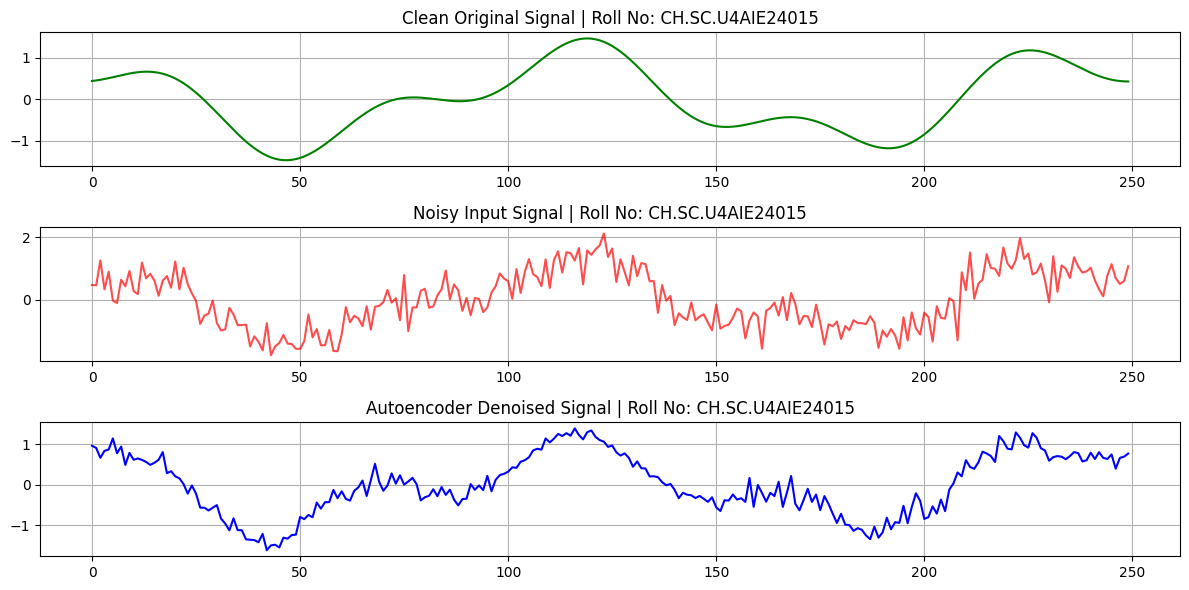

In [1]:
# Experiment 7: Denoising a Signal using Deep Learning (Autoencoder-based)
# File: Exp_07_Signal_Denoising_Autoencoder.ipynb
# Student Roll Number: CH.SC.U4AIE24015

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("=" * 60)
print("Student Roll Number: CH.SC.U4AIE24015")
print("Experiment 7: 1D Signal Denoising Autoencoder")
print("=" * 60)

# Generate synthetic sinusoidal clean signal
t = np.linspace(0, 100, 2000)
clean_signal = np.sin(t) + 0.5 * np.sin(2.5 * t)
noisy_signal = clean_signal + np.random.normal(0, 0.4, size=clean_signal.shape)

# Window the signal into frames of size 50
window_size = 50
def make_windows(sig, size):
    windows = []
    for i in range(0, len(sig) - size, size):
        windows.append(sig[i:i + size])
    return np.array(windows)

clean_windows = make_windows(clean_signal, window_size)
noisy_windows = make_windows(noisy_signal, window_size)

# Train/Test Split
split = int(0.8 * len(clean_windows))
X_train_noisy, X_test_noisy = noisy_windows[:split], noisy_windows[split:]
X_train_clean, X_test_clean = clean_windows[:split], clean_windows[split:]

# Autoencoder Architecture
autoencoder = keras.Sequential([
    layers.Input(shape=(window_size,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),   # Bottleneck
    layers.Dense(16, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(window_size, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
history = autoencoder.fit(
    X_train_noisy, X_train_clean,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_noisy, X_test_clean),
    verbose=0
)

test_loss = autoencoder.evaluate(X_test_noisy, X_test_clean, verbose=0)
print(f"[Roll No: CH.SC.U4AIE24015] Denoising Autoencoder Test Reconstruction MSE: {test_loss:.5f}")

# Reconstruct denoised windows
denoised_test_windows = autoencoder.predict(X_test_noisy, verbose=0)

clean_reconstructed = X_test_clean.flatten()
noisy_reconstructed = X_test_noisy.flatten()
denoised_reconstructed = denoised_test_windows.flatten()

# Plot Comparison
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(clean_reconstructed[:250], color="green")
plt.title(f"Clean Original Signal | Roll No: CH.SC.U4AIE24015")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(noisy_reconstructed[:250], color="red", alpha=0.7)
plt.title(f"Noisy Input Signal | Roll No: CH.SC.U4AIE24015")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(denoised_reconstructed[:250], color="blue")
plt.title(f"Autoencoder Denoised Signal | Roll No: CH.SC.U4AIE24015")
plt.grid(True)

plt.tight_layout()
plt.show()
